In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
labels=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\structured_labels.csv')
light_curve=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\structured_light_curve.csv')
info=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\structured_info.csv')

In [3]:
labels.head()

,Classification,TransientID
0,Flare,1611101400424116462
1,HPM,1611091630244128695
2,CV,1611091600294129774
3,SN,1611091210484112960
4,SN,1611091120214135441


In [4]:
labels.Classification.value_counts()

Classification
SN          1537
CV           943
AGN          427
HPM          330
Blazar       239
Flare        215
Var           49
Ast           24
YSO           21
Mira          20
Comet         14
LPV           11
Nova           7
SDSS           2
QSO            2
RRL            2
Carbon         2
Carb           2
Variable       2
LHS_5157       1
RCorB          1
GRB            1
OH_IR          1
RRLyrae        1
FU             1
AGB            1
UvES           1
Maser          1
OH-IR          1
Very           1
Red            1
Name: count, dtype: int64

In [5]:
labels.Classification.nunique()

31

Text(0.5, 1.0, 'the bar plot of classification in labels')

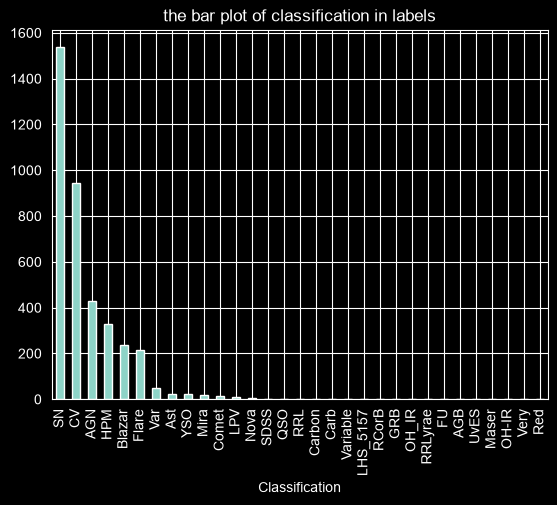

In [6]:
ax=labels.Classification.value_counts().plot(kind='bar')
ax.set_title('the bar plot of classification in labels')

Text(0.5, 1.0, 'SV vs non-SV bar plot')

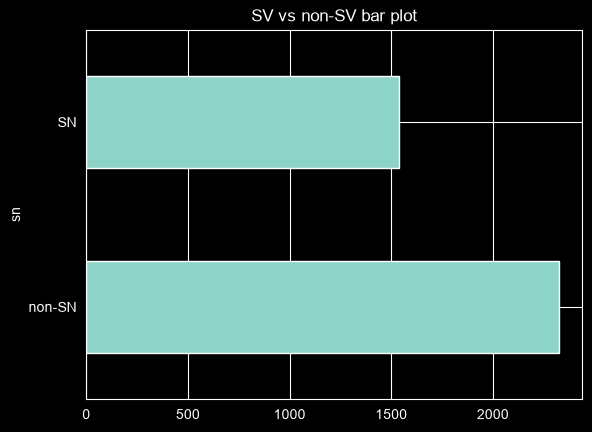

In [7]:
assigned_labels=labels.assign(sn=lambda x:np.where(x.Classification.str.contains('SN'),'SN','non-SN'))
assigned_labels.head()
ax=assigned_labels.sn.value_counts().plot(kind='barh')
ax.set_title('SV vs non-SV bar plot')

In [8]:
assigned_labels.sn.value_counts(normalize=True)*100

sn
non-SN    60.19166
SN        39.80834
Name: proportion, dtype: float64

In [9]:
"""The structured dataset contains 3,861 transients, with 1,537 classified as SN (39.81%) and 2,324 classified as non-SN (60.19%). The target is moderately imbalanced toward non-SN, with approximately 1.5 non-SN objects for every SN. The imbalance is not extreme, but evaluation should consider metrics beyond accuracy."""

'The structured dataset contains 3,861 transients, with 1,537 classified as SN (39.81%) and 2,324 classified as non-SN (60.19%). The target is moderately imbalanced toward non-SN, with approximately 1.5 non-SN objects for every SN. The imbalance is not extreme, but evaluation should consider metrics beyond accuracy.'

In [10]:
info.head()

,#CRTS ID,RA (J2000),Dec (J2000),UT Date,Mag,CSS images,SDSS,Others,Followed,Last,LC,FC,Classification
0,CSS120828:000010-215515,0.04323,-21.92087,20120828.38,17.02,1208280210014111715,no,11171,no,2016-10-22,11171,yes,Var
1,CSS100910:000025+332543,0.10280,33.42861,20100910.42,15.85,1009101320014148188,yes,14818,no,2016-11-05,14818,yes,"CV SDSS mag 20,5"
2,CSS101127:000130+050624,0.37695,5.10657,20101127.21,15.68,1011271040014129121,no,12912,yes,2016-11-06,12912,yes,"CV mag 20,0"
3,CSS160709:000132+211336,0.38474,21.22680,20160709.45,17.21,1607091210014124380,yes,12438,no,2016-11-05,12438,yes,Blazar CRATES_J0001+2113
4,CSS110926:000156+065236,0.48205,6.87665,20110926.30,19.35,1109261070014122864,no,12286,yes,2016-11-06,12286,yes,"SN 2011hl SDSS mag 15,7 2MASX_00015920"


<Axes: >

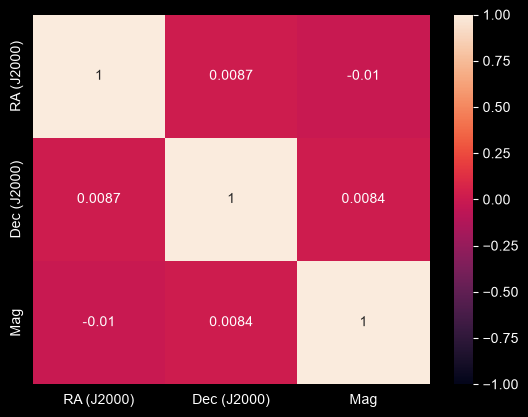

In [11]:
info_numeric=info.drop(columns=['CSS images','#CRTS ID','LC','Others','UT Date'])
sns.heatmap(info_numeric.corr(numeric_only=True),annot=True,vmin=-1,vmax=1)

In [12]:
info['CSS images'].dtypes

dtype('int64')

In [13]:
labels['TransientID'].dtypes

dtype('int64')

In [14]:
merge_label_info=assigned_labels.merge(info,left_on='TransientID',right_on='CSS images',suffixes=['_L','_I']).sort_index(axis=1)
merge_label_info.head()

,#CRTS ID,CSS images,Classification_I,Classification_L,Dec (J2000),FC,Followed,LC,Last,Mag,Others,RA (J2000),SDSS,TransientID,UT Date,sn
0,CSS161110:100924+404333,1611101400424116462,"Flare SDSS mag 20,4",Flare,40.72580,yes,no,11646,2016-11-10,18.41,11646,152.34908,yes,1611101400424116462,20161110.50,non-SN
1,CSS161109:093408+642248,1611091630244128695,HPM G_235-29,HPM,64.38013,yes,no,12869,2016-11-09,13.83,12869,143.53166,yes,1611091630244128695,20161109.33,non-SN
2,CSS161109:102925+612835,1611091600294129774,"CV SDSS mag >22,5",CV,61.47645,yes,no,12977,2016-11-09,17.11,12977,157.35429,yes,1611091600294129774,20161109.44,non-SN
3,CSS161109:093032+203629,1611091210484112960,"SN SDSS mag 20,8",SN,20.60814,yes,no,11296,2016-11-09,18.44,11296,142.63453,yes,1611091210484112960,20161109.49,SN
4,CSS161109:035036+135451,1611091120214135441,SN (ATLAS16dsr) SDSS mag,SN,13.91412,yes,no,13544,2016-11-09,17.51,13544,57.65194,no,1611091120214135441,20161109.24,SN


Text(0.5, 1.0, 'Box plot of mag(brightness) by supernova or not')

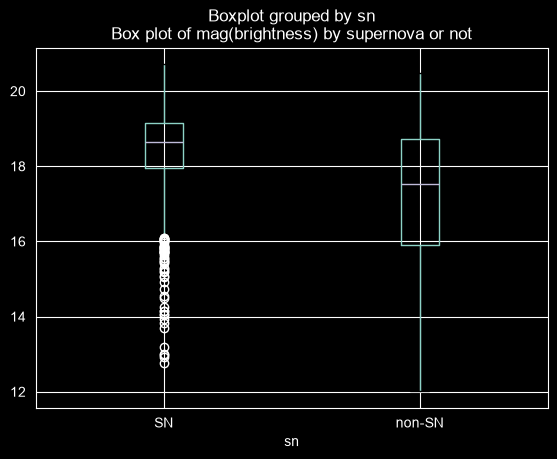

In [15]:
ax=merge_label_info.boxplot(column='Mag',by='sn')
ax.set_title('Box plot of mag(brightness) by supernova or not')

<Axes: xlabel='Mag', ylabel='Count'>

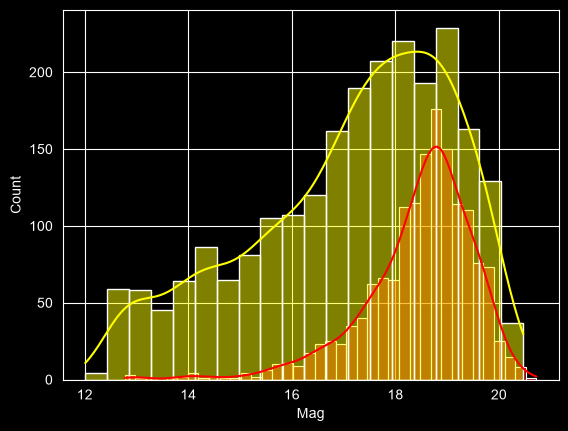

In [16]:
fig,axes=plt.subplots(1,1)
sns.histplot(merge_label_info[merge_label_info.sn=='SN'].Mag,kde=True,color='red',alpha=0.5,ax=axes)
sns.histplot(merge_label_info[merge_label_info.sn=='non-SN'].Mag,kde=True,color='yellow',alpha=0.5,ax=axes)

Text(0.5, 1.0, 'scatter plot of mag(brightness) by transient')

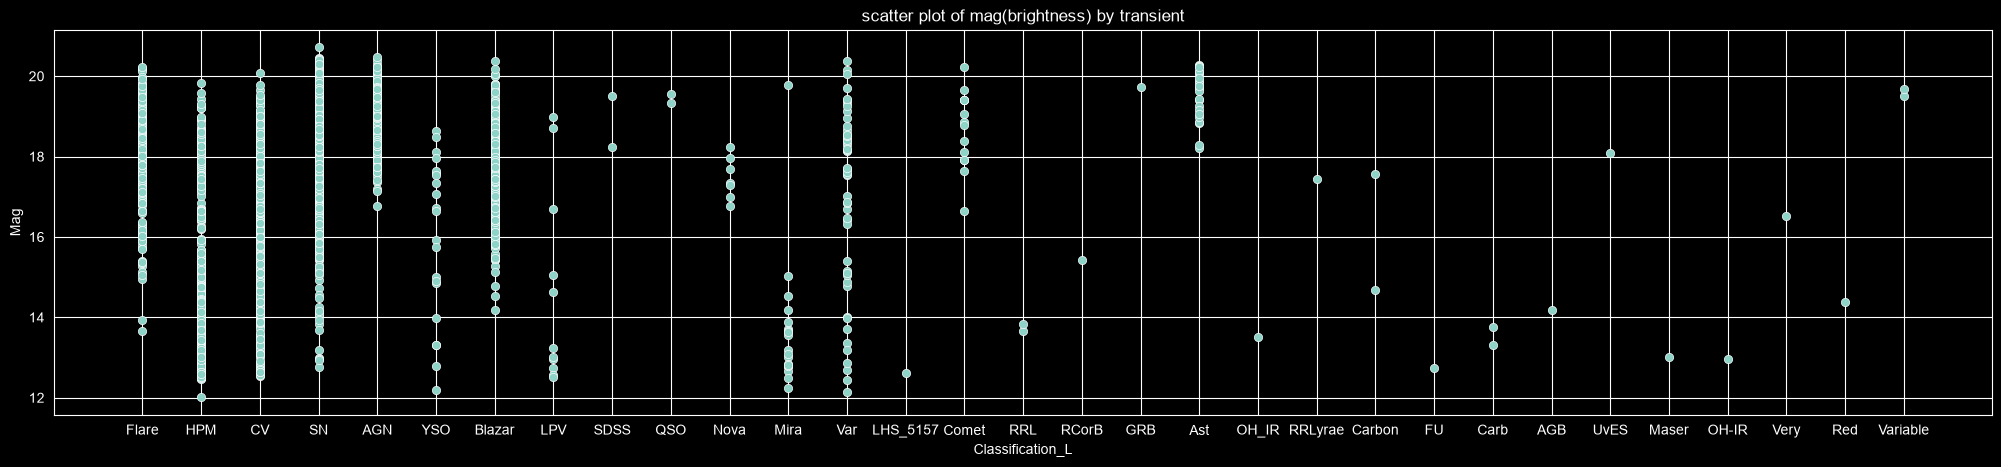

In [17]:
fig,ax=plt.subplots(1,1,figsize=(25,5))
sns.scatterplot(merge_label_info,y='Mag',x='Classification_L',ax=ax)
ax.set_title('scatter plot of mag(brightness) by transient')

In [18]:
merge_label_info.assign(count=1).groupby('Classification_L').agg({
    'Mag':'mean',
    'count':'count'
}).sort_values(by='count',ascending=False)

,Mag,count
Classification_L,,
SN,18.453598,1537
CV,16.725981,943
AGN,19.150328,427
HPM,15.095515,330
Blazar,17.765690,239
Flare,17.977116,215
Var,16.945510,49
Ast,19.552083,24
YSO,15.985714,21


Text(0.5, 1.0, 'violin plot of brightness(mag) by transient objects')

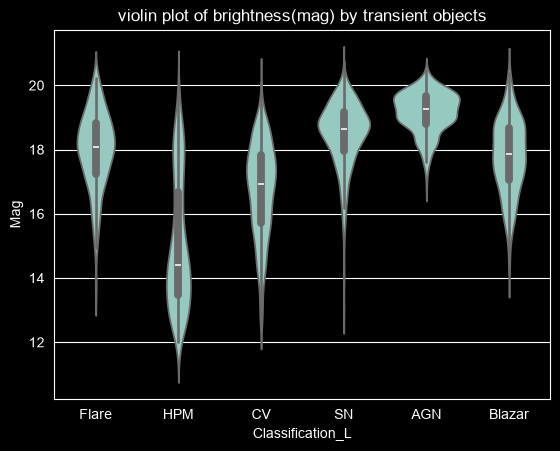

In [19]:
lists=['SN','CV','AGN','HPM','Blazar','Flare']
ax=sns.violinplot(merge_label_info[merge_label_info['Classification_L'].isin(lists)],x='Classification_L',y='Mag',inner='box')
ax.set_title('violin plot of brightness(mag) by transient objects')

In [20]:
pd.crosstab(
    index=merge_label_info['sn'],columns=merge_label_info['FC'],normalize='index'
)*100

FC,no,yes
sn,,
SN,15.940143,84.059857
non-SN,14.156627,85.843373


In [21]:
pd.crosstab(index=merge_label_info['sn'],columns=merge_label_info['Followed'],normalize='index')*100

Followed,no,yes
sn,,
SN,67.664281,32.335719
non-SN,68.975904,31.024096


In [22]:
pd.crosstab(index=merge_label_info['sn'],columns=merge_label_info['SDSS'],normalize='index')*100

SDSS,no,yes
sn,,
SN,16.916070,83.083930
non-SN,28.700516,71.299484


In [23]:
percent=pd.crosstab(index=merge_label_info['Classification_L'],columns=merge_label_info['SDSS'],normalize='index')*100
count=pd.crosstab(index=merge_label_info['Classification_L'],columns=merge_label_info['SDSS'],margins=True)
pd.concat([count.add_suffix('_count'),percent.add_suffix('_percent')],axis=1).sort_values(by='All_count',ascending=False)

SDSS,no_count,yes_count,All_count,no_percent,yes_percent
Classification_L,,,,,
All,927,2934,3861,NaN,NaN
SN,260,1277,1537,16.916070,83.083930
CV,348,595,943,36.903499,63.096501
AGN,54,373,427,12.646370,87.353630
HPM,75,255,330,22.727273,77.272727
Blazar,67,172,239,28.033473,71.966527
Flare,57,158,215,26.511628,73.488372
Var,25,24,49,51.020408,48.979592
Ast,7,17,24,29.166667,70.833333


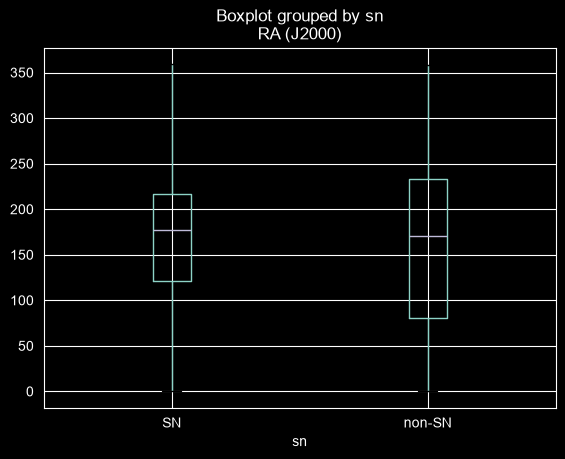

In [24]:
ax=merge_label_info.boxplot(by='sn',column='RA (J2000)')

<Axes: xlabel='Classification_L', ylabel='RA (J2000)'>

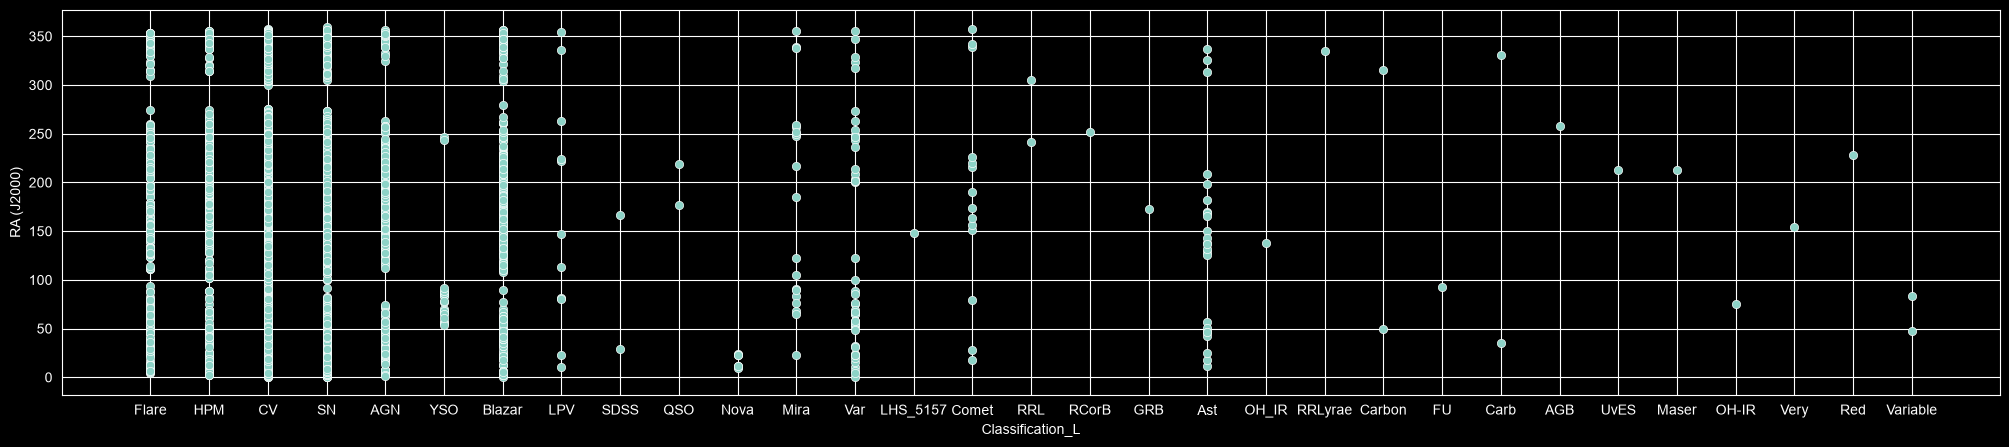

In [25]:
fig,ax=plt.subplots(1,1,figsize=(25,5))
sns.scatterplot(merge_label_info,x='Classification_L',y='RA (J2000)')

In [26]:
merge_label_info.assign(count=1).groupby('Classification_L').agg({
    'count':'count',
    'RA (J2000)':['mean','median'],
    'Dec (J2000)':['mean','median']
}).sort_values(by=('count','count'),ascending=False)

count  RA (J2000)             Dec (J2000)           
                 count        mean      median        mean     median
Classification_L                                                     
SN                1537  164.875421  177.259040   16.743949  17.209890
CV                 943  175.427030  163.779130   14.627593  14.202790
AGN                427  165.239666  178.976290   18.535575  18.000410
HPM                330  167.185200  183.799595   24.176968  26.581055
Blazar             239  170.209457  179.110890   16.356214  15.556440
Flare              215  159.900464  157.689020   13.713502  12.502590
Var                 49  134.693341   75.875610   13.229816  14.665800
Ast                 24  138.235784  137.257420   12.224263  12.913980
YSO                 21   90.701713   78.498450   12.398655  11.771950
Mira                20  183.685459  200.973265    6.521501   2.067885
Comet               14  189.964679  181.624590   10.392140   8.978475
LPV                 11  168.736369  146.989050   15.168993  13.279010
Nova                 7   16.087469   11.088830   36.612217  40.651360
Carbon               2  182.393755  182.393755   13.522475  13.522475
Carb                 2  183.086535  183.086535   17.997865  17.997865
Variable             2   65.294230   65.294230   10.638415  10.638415
SDSS                 2   98.007275   98.007275   39.550735  39.550735
RRL                  2  273.257040  273.257040    9.665315   9.665315
QSO                  2  197.904750  197.904750    7.535120   7.535120
AGB                  1  258.242030  258.242030   -6.049100  -6.049100
LHS_5157             1  148.387040  148.387040   51.251970  51.251970
FU                   1   92.330480   92.330480   -6.698710  -6.698710
GRB                  1  173.137080  173.137080   27.699020  27.699020
Maser                1  212.823220  212.823220   -7.747360  -7.747360
RCorB                1  251.873980  251.873980  -15.423230 -15.423230
OH-IR                1   75.102470   75.102470   12.935080  12.935080
OH_IR                1  137.792260  137.792260  -22.036780 -22.036780
RRLyrae              1  334.805180  334.805180   24.201460  24.201460
Red                  1  228.357380  228.357380  -15.733300 -15.733300
UvES                 1  212.887670  212.887670    2.372590   2.372590
Very                 1  153.858080  153.858080   -2.075600  -2.075600

Text(0.5, 1.0, 'violin graph of Dec(J200) for some transient objects')

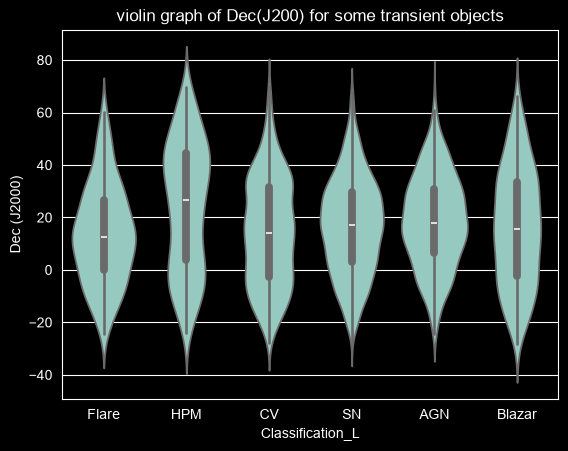

In [27]:
sns.violinplot(merge_label_info[merge_label_info.Classification_L.isin(lists)],x='Classification_L',y='Dec (J2000)')
plt.title('violin graph of Dec(J200) for some transient objects')

In [28]:
light_curve.head()

,ID,observation_id,Mag,Magerr,MJD
0,TranID1209210010044118805,13,20.2378,0.316525,53710.098919
1,TranID1209210010044118805,14,20.2106,0.339888,53563.432943
2,TranID1209210010044118805,15,19.8779,0.266032,53703.072637
3,TranID1209210010044118805,16,20.4570,0.392199,53650.288893
4,TranID1209210010044118805,17,20.5868,0.389254,53670.268145


In [29]:
light_curve_grouped = (
    light_curve
    .groupby('ID')
    .agg(
        count=('ID', 'size'),
        mag_mean=('Mag', 'mean'),
        mag_median=('Mag','median'),
        mag_std=('Mag','std'),
        mag_min=('Mag','min'),
        mag_max=('Mag','max'),
        magerr_mean=('Magerr', 'mean'),
        magerr_median=('Magerr','median'),
        magerr_std=('Magerr','std'),
        magerr_min=('Magerr','min'),
        magerr_max=('Magerr','max'),
        mjd_mean=('MJD', 'mean'),
        mjd_median=('MJD','median'),
        mjd_std=('MJD','std'),
        mjd_min=('MJD','min'),
        mjd_max=('MJD','max')
        )
).sort_values(by='count',ascending=False)
light_curve_grouped.head()

,count,mag_mean,mag_median,mag_std,mag_min,mag_max,magerr_mean,magerr_median,magerr_std,magerr_min,magerr_max,mjd_mean,mjd_median,mjd_std,mjd_min,mjd_max
ID,,,,,,,,,,,,,,,,
TranID1502081400484121702,564,19.070212,19.0480,0.563520,17.4679,21.0005,0.188963,0.173111,0.070396,0.097572,0.803396,54954.935599,54881.393312,863.304859,53527.200365,56450.199873
TranID1304111230414140313,524,18.290647,18.3195,0.223333,16.2467,18.7146,0.132789,0.126121,0.030000,0.069411,0.384792,55004.243489,55085.487921,918.850484,53470.137321,56596.408415
TranID801301180474127786,523,15.852289,15.9439,0.639477,12.5904,16.9140,0.067007,0.065450,0.010494,0.050634,0.172967,55063.462770,55126.502577,949.154129,53469.186245,56590.486708
TranID803051320384107064,519,18.041954,18.4395,1.202582,14.2813,19.7451,0.132096,0.132977,0.049156,0.054620,0.583440,54999.895371,54918.147618,874.121207,53480.228702,56559.483592
TranID1104041230404151904,517,16.156232,16.2702,0.352611,14.5120,17.6972,0.070845,0.069299,0.009577,0.057730,0.131279,55003.716282,55085.485167,919.198784,53470.136833,56596.408918


In [30]:
light_curve_grouped.shape

(3861, 16)

In [31]:
light_curve_grouped=light_curve_grouped.assign(TransientID=lambda x:x.index.str.replace('TranID','',regex=False).astype(int)).set_index('TransientID')
light_curve_grouped.head()

,count,mag_mean,mag_median,mag_std,mag_min,mag_max,magerr_mean,magerr_median,magerr_std,magerr_min,magerr_max,mjd_mean,mjd_median,mjd_std,mjd_min,mjd_max
TransientID,,,,,,,,,,,,,,,,
1502081400484121702,564,19.070212,19.0480,0.563520,17.4679,21.0005,0.188963,0.173111,0.070396,0.097572,0.803396,54954.935599,54881.393312,863.304859,53527.200365,56450.199873
1304111230414140313,524,18.290647,18.3195,0.223333,16.2467,18.7146,0.132789,0.126121,0.030000,0.069411,0.384792,55004.243489,55085.487921,918.850484,53470.137321,56596.408415
801301180474127786,523,15.852289,15.9439,0.639477,12.5904,16.9140,0.067007,0.065450,0.010494,0.050634,0.172967,55063.462770,55126.502577,949.154129,53469.186245,56590.486708
803051320384107064,519,18.041954,18.4395,1.202582,14.2813,19.7451,0.132096,0.132977,0.049156,0.054620,0.583440,54999.895371,54918.147618,874.121207,53480.228702,56559.483592
1104041230404151904,517,16.156232,16.2702,0.352611,14.5120,17.6972,0.070845,0.069299,0.009577,0.057730,0.131279,55003.716282,55085.485167,919.198784,53470.136833,56596.408918


In [32]:
info_some_values=info[['Dec (J2000)','Mag','CSS images','SDSS']].rename(columns={
    'CSS images':'TransientID',
    'Mag':'mag_info'
}).set_index('TransientID')
merge_all=labels.set_index('TransientID').join(light_curve_grouped,lsuffix='_label',rsuffix='light').sort_values(by='count',ascending=False).join(info_some_values).sort_index(axis=1)
merge_all=merge_all.assign(SN=lambda x:np.where(x.Classification=='SN',1,0))
merge_all.head()

,Classification,Dec (J2000),SDSS,count,mag_info,mag_max,mag_mean,mag_median,mag_min,mag_std,...,magerr_mean,magerr_median,magerr_min,magerr_std,mjd_max,mjd_mean,mjd_median,mjd_min,mjd_std,SN
TransientID,,,,,,,,,,,,,,,,,,,,,
1502081400484121702,Blazar,41.23145,yes,564,18.15,21.0005,19.070212,19.0480,17.4679,0.563520,...,0.188963,0.173111,0.097572,0.070396,56450.199873,54954.935599,54881.393312,53527.200365,863.304859,0
1304111230414140313,Flare,24.62151,yes,524,17.83,18.7146,18.290647,18.3195,16.2467,0.223333,...,0.132789,0.126121,0.069411,0.030000,56596.408415,55004.243489,55085.487921,53470.137321,918.850484,0
801301180474127786,CV,18.82975,yes,523,12.64,16.9140,15.852289,15.9439,12.5904,0.639477,...,0.067007,0.065450,0.050634,0.010494,56590.486708,55063.462770,55126.502577,53469.186245,949.154129,0
803051320384107064,CV,31.51837,yes,519,14.66,19.7451,18.041954,18.4395,14.2813,1.202582,...,0.132096,0.132977,0.054620,0.049156,56559.483592,54999.895371,54918.147618,53480.228702,874.121207,0
1104041230404151904,CV,25.27449,yes,517,15.30,17.6972,16.156232,16.2702,14.5120,0.352611,...,0.070845,0.069299,0.057730,0.009577,56596.408918,55003.716282,55085.485167,53470.136833,919.198784,0


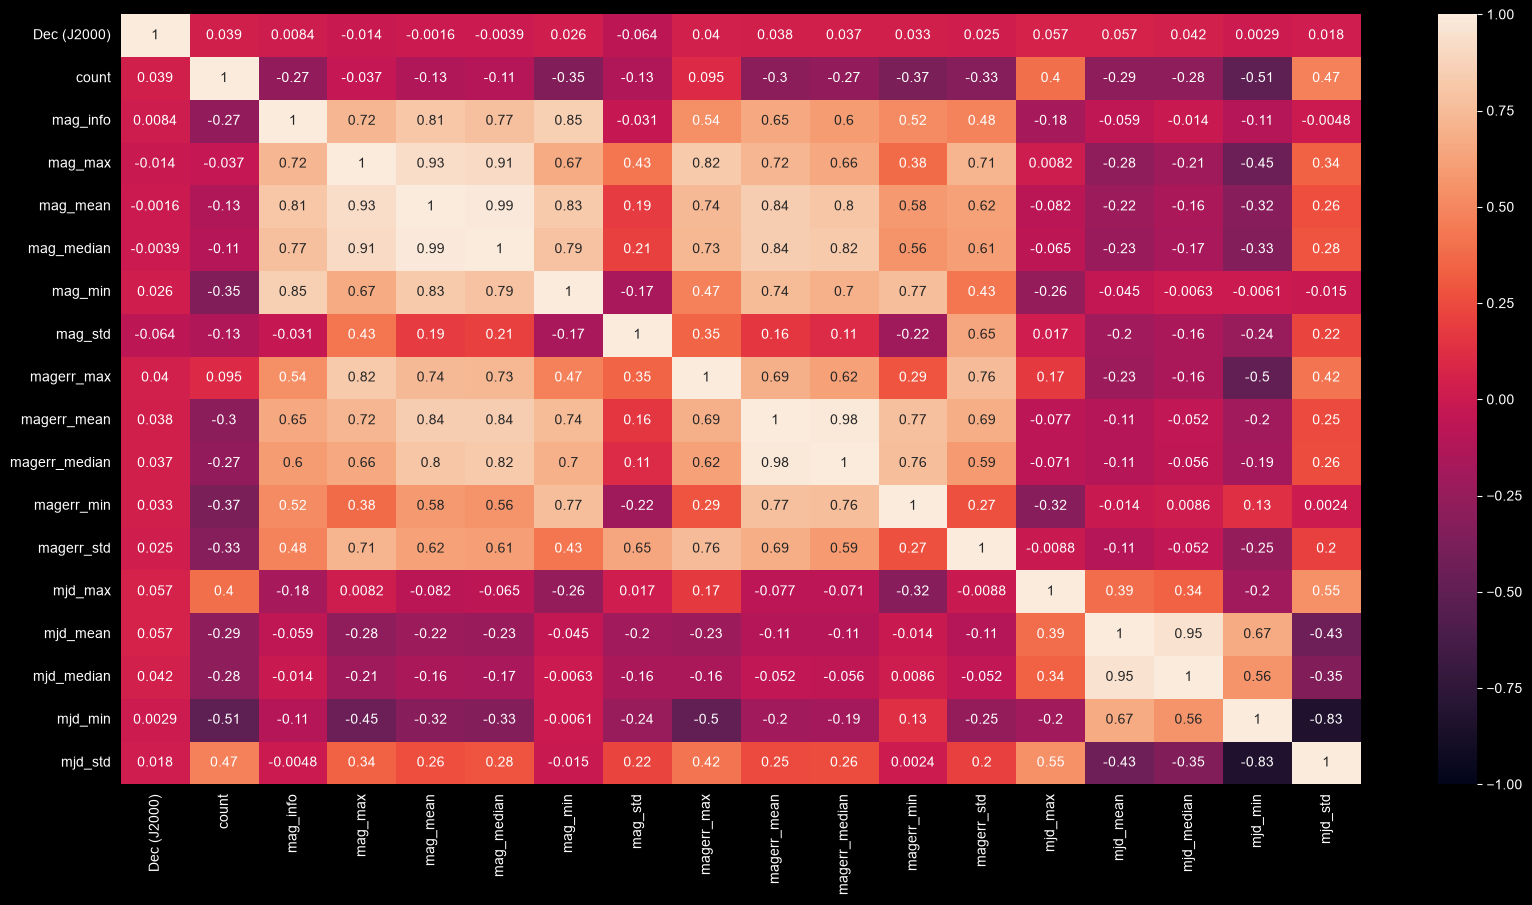

In [33]:
checker=merge_all.drop(columns='SN')
fig,ax=plt.subplots(1,1,figsize=(20,10))
sns.heatmap(checker.corr(numeric_only=True),vmin=-1,vmax=1,annot=True)
plt.savefig('heatmap.pdf',dpi=300,bbox_inches='tight')

<Axes: title={'center': 'mag_std'}, xlabel='SN'>

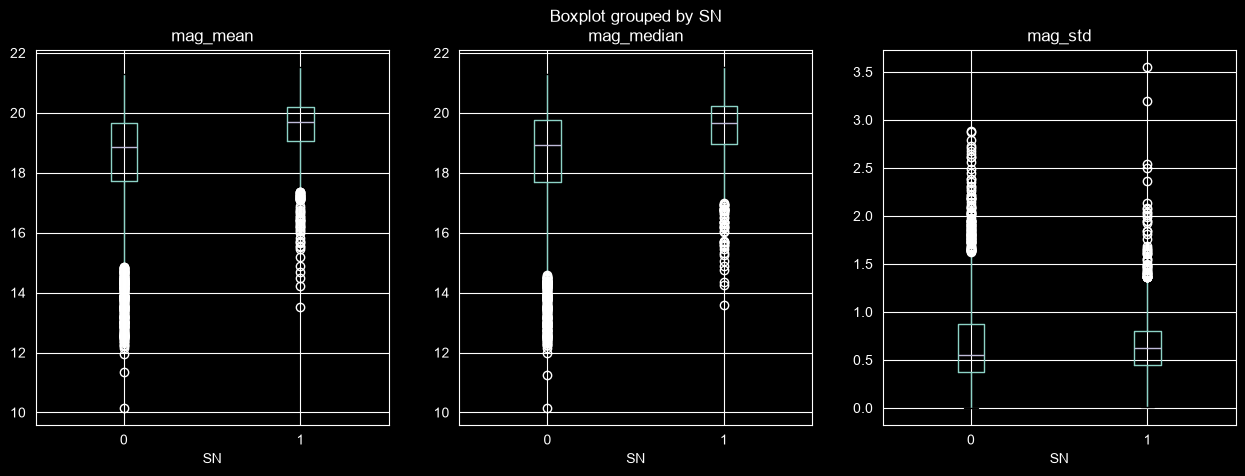

In [34]:
fig,ax=plt.subplots(1,3,figsize=(15,5))
merge_all.boxplot(by='SN',column='mag_mean',ax=ax[0])
merge_all.boxplot(by='SN',column='mag_median',ax=ax[1])
merge_all.boxplot(by='SN',column='mag_std',ax=ax[2])

In [35]:
grouped_by_classification=merge_all.assign(count=1).groupby('Classification').agg(
    count=('count','count'),
    mean=('mag_mean','mean'),
    median=('mag_median','median')
).sort_values(by='count',ascending=False)
grouped_by_classification

,count,mean,median
Classification,,,
SN,1537,19.515996,19.657600
CV,943,18.575797,18.779700
AGN,427,19.694530,19.774750
HPM,330,15.079872,14.399900
Blazar,239,18.998009,19.212250
Flare,215,19.204282,19.353950
Var,49,17.641367,18.388400
Ast,24,19.623907,19.722350
YSO,21,17.011615,17.628850


<Axes: xlabel='Classification', ylabel='mag_mean'>

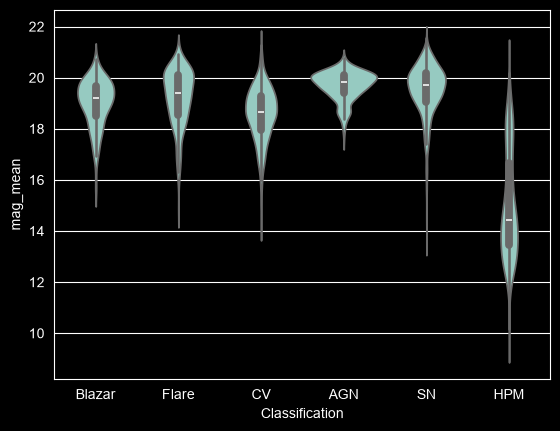

In [36]:
sns.violinplot(merge_all[merge_all.Classification.isin(lists)],x='Classification',y='mag_mean')

<Axes: xlabel='Classification', ylabel='mag_median'>

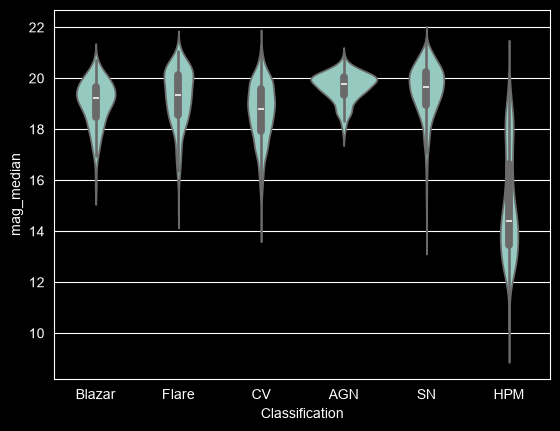

In [37]:
sns.violinplot(merge_all[merge_all.Classification.isin(lists)],x='Classification',y='mag_median')

<Axes: xlabel='Classification', ylabel='mag_std'>

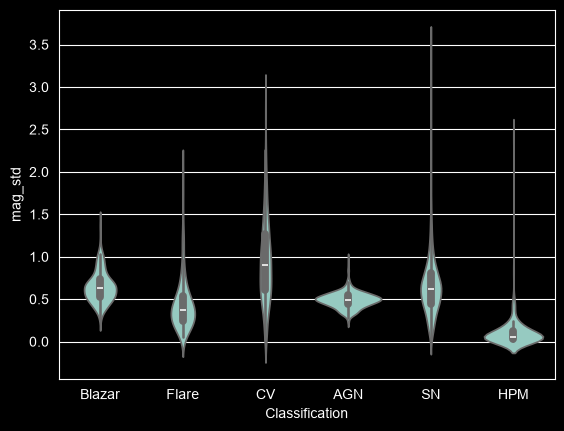

In [38]:
sns.violinplot(merge_all[merge_all.Classification.isin(lists)],x='Classification',y='mag_std')

Text(0.57, -0.1, 'Standard Deviation')

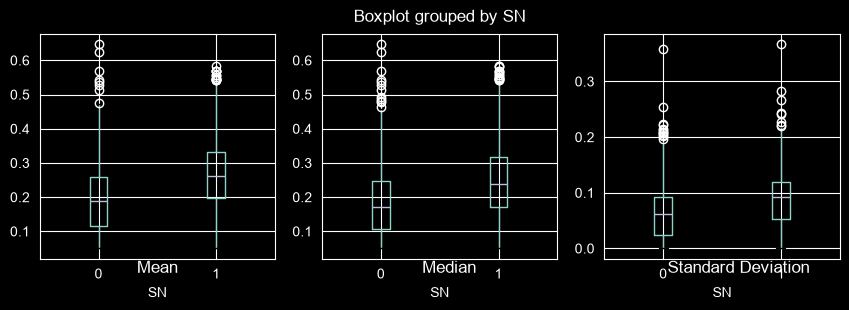

In [39]:
fig,ax=plt.subplots(1,3,figsize=(10,3))
merge_all.boxplot(by='SN',column='magerr_mean',ax=ax[0])
merge_all.boxplot(by='SN',column='magerr_median',ax=ax[1])
merge_all.boxplot(by='SN',column='magerr_std',ax=ax[2])
for a in ax:
    a.set_title('')
ax[0].set_title('Mean',x=0.5,y=-0.1)
ax[1].set_title('Median',x=0.54,y=-0.1)
ax[2].set_title('Standard Deviation',x=0.57,y=-0.1)

In [40]:
merge_all.assign(count=1).groupby('Classification').agg({
    'count':'count',
    'magerr_mean':'mean',
    'magerr_median':'median',
    'magerr_std':'std'
}).sort_values(by='count',ascending=False)

,count,magerr_mean,magerr_median,magerr_std
Classification,,,,
SN,1537,0.267033,0.237696,0.045327
CV,943,0.192936,0.161074,0.049087
AGN,427,0.260650,0.249472,0.021595
HPM,330,0.075871,0.055570,0.015239
Blazar,239,0.206719,0.189964,0.030178
Flare,215,0.234753,0.205220,0.044942
Var,49,0.159150,0.134291,0.036728
Ast,24,0.250676,0.236707,0.048415
YSO,21,0.123312,0.106606,0.029652


In [41]:
merge_all.assign(count=1).groupby('Classification').agg({
    'count':'count',
    'magerr_max':'max',
    'magerr_min':'min',
}).assign(difference=lambda x:x.magerr_max-x.magerr_min).sort_values(by='count',ascending=False)

,count,magerr_max,magerr_min,difference
Classification,,,,
SN,1537,1.083763,0.051045,1.032718
CV,943,1.306650,0.050189,1.256461
AGN,427,1.052631,0.057796,0.994836
HPM,330,0.647715,0.049932,0.597783
Blazar,239,1.101914,0.053334,1.048580
Flare,215,0.835707,0.051184,0.784522
Var,49,0.853606,0.050443,0.803164
Ast,24,0.568428,0.116549,0.451880
YSO,21,0.595073,0.050841,0.544232


<Axes: title={'center': 'mjd_median'}, xlabel='SN'>

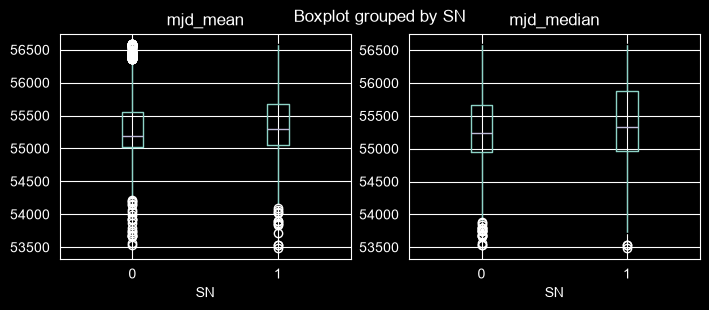

In [42]:
fig,ax=plt.subplots(1,2,figsize=(8,3))
merge_all.boxplot(by='SN',column='mjd_mean',ax=ax[0])
merge_all.boxplot(by='SN',column='mjd_median',ax=ax[1])

In [43]:
merge_all_b=merge_all.assign(baseline=lambda x:x.mjd_max-x.mjd_min).sort_values(by='baseline',ascending=False)
merge_all_b.head(10)

,Classification,Dec (J2000),SDSS,count,mag_info,mag_max,mag_mean,mag_median,mag_min,mag_std,...,magerr_median,magerr_min,magerr_std,mjd_max,mjd_mean,mjd_median,mjd_min,mjd_std,SN,baseline
TransientID,,,,,,,,,,,,,,,,,,,,,
1403041090444115966,CV,9.13311,yes,196,14.30,21.3497,19.644892,19.89535,14.4134,1.250493,...,0.252655,0.057454,0.105340,56596.456166,55101.962091,55165.939170,53466.161646,904.173909,0,3130.294521
1303171090424146629,CV,10.00458,yes,123,16.72,19.3268,18.295426,18.43210,15.4889,0.651653,...,0.129053,0.066527,0.071441,56596.457178,55420.695174,55586.301298,53466.162729,798.608341,0,3130.294448
1410301120434103505,Var,11.42750,yes,384,17.53,19.2546,18.431063,18.45010,15.5845,0.339290,...,0.134291,0.060049,0.043817,56596.452534,55055.065413,55104.502721,53466.166456,880.325562,0,3130.286078
1412301120594110654,Blazar,11.97137,yes,361,16.38,20.7025,18.816721,18.80880,17.5213,0.423471,...,0.153389,0.095238,0.063721,56596.511525,55154.509825,55275.320903,53466.229324,924.380654,0,3130.282201
904181120584134509,CV,13.26448,yes,385,14.97,20.3012,18.474386,18.81100,14.5663,1.253751,...,0.155104,0.056058,0.065930,56596.512028,55087.457115,55160.494566,53466.229852,948.655764,0,3130.282176
1505101120564109481,SN,11.93391,yes,104,19.51,21.3261,20.328512,20.32065,19.2060,0.416843,...,0.331777,0.182232,0.081307,56596.506941,55394.036193,55563.414260,53466.230911,896.887721,1,3130.276030
1304291120584117616,SN,12.62213,yes,72,18.94,21.4544,20.080186,20.25475,16.9159,0.855592,...,0.304030,0.081412,0.105779,56596.505927,55346.226328,55450.334355,53466.248087,960.831623,1,3130.257840
1305141070524109313,CV,6.17894,yes,121,14.70,21.3039,19.456550,19.91990,14.6764,1.553578,...,0.244658,0.057029,0.106334,56596.480968,55167.482861,55162.471428,53466.225334,918.613013,0,3130.255633
909301120444140061,CV,13.30685,yes,409,14.45,20.5634,18.957305,19.16980,14.0282,1.177842,...,0.183901,0.053623,0.063288,56596.452032,55050.563228,55104.505350,53466.197347,851.698323,0,3130.254685


<Axes: xlabel='baseline', ylabel='count'>

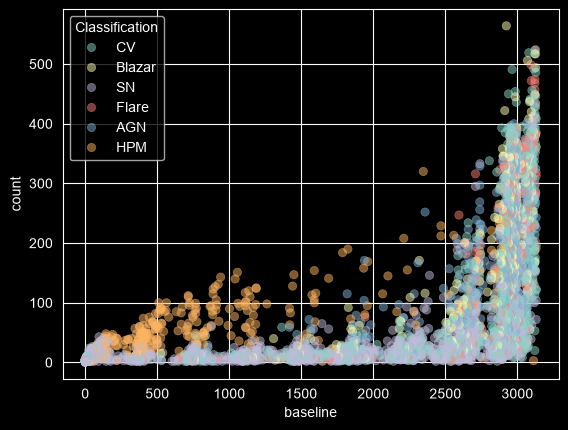

In [44]:
sns.scatterplot(merge_all_b[merge_all_b.Classification.isin(lists)],x='baseline',y='count',hue='Classification',alpha=0.5,edgecolor=None)

<Axes: xlabel='baseline', ylabel='count'>

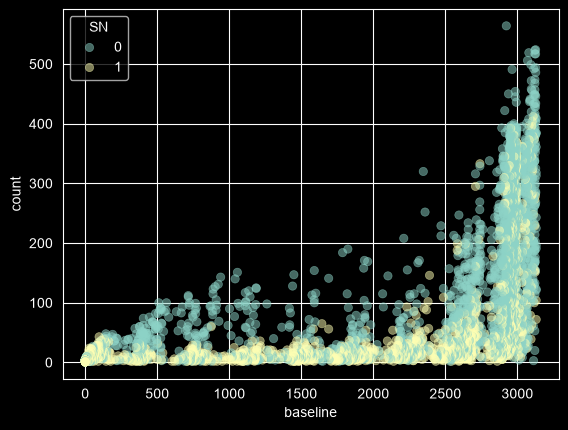

In [45]:
sns.scatterplot(merge_all_b,x='baseline',y='count',hue='SN',edgecolor=None,alpha=0.5)

<Axes: xlabel='baseline', ylabel='count'>

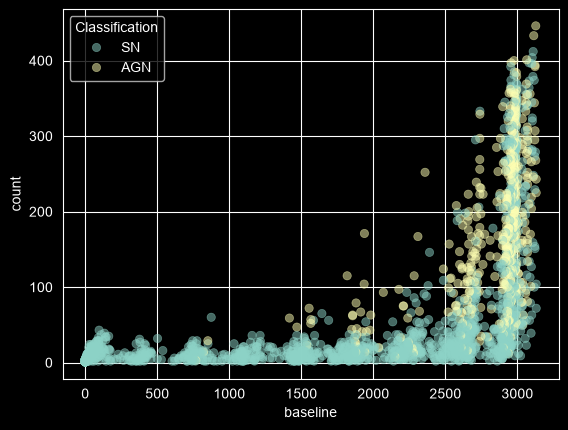

In [46]:
agn_sn=['AGN','SN']
sns.scatterplot(merge_all_b[merge_all_b.Classification.isin(agn_sn)],x='baseline',y='count',hue='Classification',edgecolor=None,alpha=0.5)

<Axes: title={'center': 'mjd_std'}, xlabel='SN'>

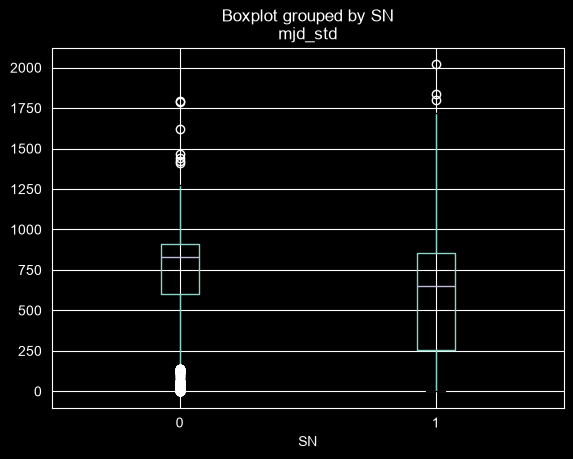

In [47]:
merge_all.boxplot(by='SN',column='mjd_std')

In [48]:
merge_all_b=merge_all_b.assign(mag_baseline=lambda x:x.mag_max-x.mag_min).sort_values(by='mag_baseline',ascending=False)
merge_all_b.head(10)

,Classification,Dec (J2000),SDSS,count,mag_info,mag_max,mag_mean,mag_median,mag_min,mag_std,...,magerr_min,magerr_std,mjd_max,mjd_mean,mjd_median,mjd_min,mjd_std,SN,baseline,mag_baseline
TransientID,,,,,,,,,,,,,,,,,,,,,
1210061091254108515,SN,8.91432,yes,196,18.31,21.3838,19.579940,19.67260,12.2208,0.826791,...,0.076059,0.082713,56588.238948,55257.395636,55369.435503,53531.441810,944.440362,1,3056.797138,9.1630
1305091120654118444,SN,12.25101,yes,44,18.88,21.5437,20.017727,20.36435,12.4589,1.414599,...,0.066165,0.126198,56464.199830,55740.174167,56003.358029,53789.385981,794.705168,1,2674.813849,9.0848
1007051071254133856,SN,8.00804,yes,9,19.08,21.3105,18.760311,19.05830,12.4652,2.544812,...,0.085729,0.171531,55469.253501,55247.811919,55369.441595,54090.116234,436.012865,1,1379.137268,8.8453
1408311210014119351,Blazar,20.79720,yes,255,17.60,20.3146,18.769760,18.89440,11.6801,1.023209,...,0.053357,0.051045,56593.217544,55117.750993,55096.343174,53648.259513,933.346573,0,2944.958031,8.6345
1502071150154145908,HPM,16.86533,no,13,12.52,20.8485,13.004977,12.35530,12.3152,2.356798,...,0.050715,0.125210,56595.318831,56361.762754,56581.289556,53755.101850,783.335895,0,2840.216981,8.5333
1304181400734166981,CV,41.79893,no,265,13.97,21.2597,19.343204,19.97100,12.7370,1.889983,...,0.051219,0.114380,56596.103779,55008.706062,54892.509170,53526.394538,949.355343,0,3069.709241,8.5227
1002171210554127510,CV,21.21863,yes,436,12.57,20.6007,19.241744,19.34660,12.5351,0.889735,...,0.050809,0.054158,56461.201825,55027.844630,54940.225230,53469.255094,878.240769,0,2991.946731,8.0656
712151210224139942,CV,21.94530,no,107,17.00,21.1734,19.288960,19.47640,13.1909,1.193377,...,0.061015,0.122758,56590.370202,55030.865142,55128.383284,53642.442181,918.346190,0,2947.928021,7.9825
712180180624111439,SN,-18.97270,no,28,12.93,20.8207,16.000861,16.00965,12.9332,1.627914,...,0.051681,0.072948,55984.365943,54585.612660,54532.345973,54452.533856,277.230098,1,1531.832087,7.8875


<Axes: xlabel='mag_baseline', ylabel='count'>

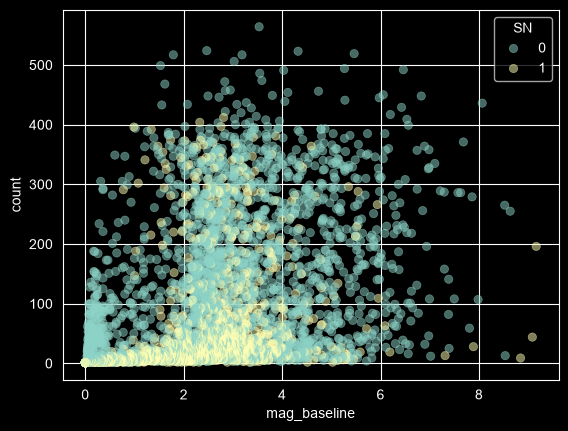

In [49]:
sns.scatterplot(merge_all_b,x='mag_baseline',y='count',hue='SN',edgecolor=None,alpha=0.5)

<Axes: xlabel='mag_baseline', ylabel='count'>

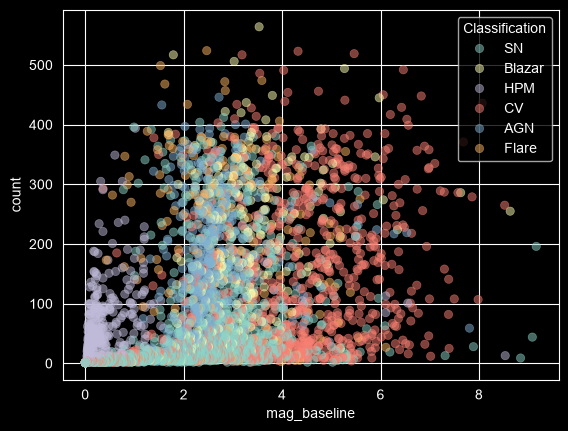

In [50]:
sns.scatterplot(merge_all_b[merge_all_b.Classification.isin(lists)],x='mag_baseline',y='count',hue='Classification',alpha=0.5,edgecolor=None)

<Axes: xlabel='mag_baseline', ylabel='count'>

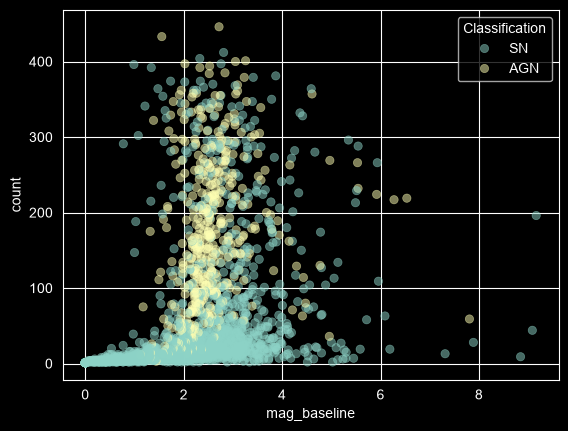

In [51]:
sns.scatterplot(merge_all_b[merge_all_b.Classification.isin(agn_sn)],x='mag_baseline',y='count',hue='Classification',alpha=0.5,edgecolor=None)

In [52]:
merge_all=merge_all_b.drop(columns=['magerr_min','mjd_min','mjd_max','mjd_mean','mjd_median','magerr_median'])
merge_all.head()

,Classification,Dec (J2000),SDSS,count,mag_info,mag_max,mag_mean,mag_median,mag_min,mag_std,magerr_max,magerr_mean,magerr_std,mjd_std,SN,baseline,mag_baseline
TransientID,,,,,,,,,,,,,,,,,
1210061091254108515,SN,8.91432,yes,196,18.31,21.3838,19.579940,19.67260,12.2208,0.826791,0.518022,0.246648,0.082713,944.440362,1,3056.797138,9.1630
1305091120654118444,SN,12.25101,yes,44,18.88,21.5437,20.017727,20.36435,12.4589,1.414599,0.630021,0.326672,0.126198,794.705168,1,2674.813849,9.0848
1007051071254133856,SN,8.00804,yes,9,19.08,21.3105,18.760311,19.05830,12.4652,2.544812,0.571777,0.248457,0.171531,436.012865,1,1379.137268,8.8453
1408311210014119351,Blazar,20.79720,yes,255,17.60,20.3146,18.769760,18.89440,11.6801,1.023209,0.620303,0.171679,0.051045,933.346573,0,2944.958031,8.6345
1502071150154145908,HPM,16.86533,no,13,12.52,20.8485,13.004977,12.35530,12.3152,2.356798,0.502200,0.085478,0.125210,783.335895,0,2840.216981,8.5333


In [53]:
merge_all.to_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\merge_all.csv')